# To build a face recogntion application. First Capture data from the web cam on the digital device. Build a data processing pipeline and dvelop the VGG16/AlexNet/ResNet18 model. Train the model and test it offline. Evaluate the trained VGG 16/AlexNet/ResNet18 model with preformace metrics and visualize the results by testing on the face data in the test set.

# Capture Faces Through Webcam

In [ ]:
import cv2      # OpenCV library for computer vision tasks
import os       # Operating system interactions for file/directory management

def create_dataset():
    """
    Create a face dataset by capturing faces from webcam.
    
    This function:
    1. Prompts user for a dataset name/class
    2. Creates a directory to store faces
    3. Captures faces using webcam and face detection
    4. Saves detected faces as images
    """
    # Prompt user to input a name or class for the dataset
    class_name = input("Enter the name or class for this dataset: ").strip()
    
    # Validate that the input is not empty
    if not class_name:
        print("Class name cannot be empty. Please try again.")
        return
    
    # Create a directory for storing the dataset
    dataset_path = os.path.join('face_dataset', class_name)
    os.makedirs(dataset_path, exist_ok=True)
    
    # Load the pre-trained Haar Cascade Classifier for face detection
    face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
    
    # Open the default webcam (index 0)
    cap = cv2.VideoCapture(0)
    
    # Verify that the webcam opened successfully
    if not cap.isOpened():
        print("Error: Could not open webcam.")
        return
    
    # Initialize variables for face capturing
    face_count = 0        # Number of faces captured
    max_faces = 500        # Maximum number of faces to capture
    
    # Inform user that face capture has started
    print(f"Starting face capture for {class_name}. Press 'q' to quit early.")
    
    # Main capture loop - continues until max faces are captured
    while face_count < max_faces:
        # Read a frame from the webcam
        ret, frame = cap.read()
        
        if not ret:
            print("Failed to grab frame")
            break
        
        # Convert the frame to grayscale
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        
        # Detect faces in the grayscale image
        faces = face_cascade.detectMultiScale(
            gray, 
            scaleFactor=1.1, 
            minNeighbors=5, 
            minSize=(30, 30)
        )
        
        # Process each detected face
        for (x, y, w, h) in faces:
            # Draw a green rectangle around the detected face
            cv2.rectangle(frame, (x, y), (x+w, y+h), (0, 255, 0), 2)
            
            # Extract the face region from the grayscale image
            face_img = gray[y:y+h, x:x+w]
            
            # Resize face to a standard size (200x200 pixels)
            face_img = cv2.resize(face_img, (200, 200))
            
            # Generate filename for the face image
            file_name = os.path.join(dataset_path, f'{class_name}_{face_count}.jpg')
            
            # Save the face image to the specified path
            cv2.imwrite(file_name, face_img)
            
            # Increment face counter
            face_count += 1
            
            # Stop capturing if max faces are reached
            if face_count >= max_faces:
                break
        
        # Add text overlay to show progress
        progress_text = f'Captured: {face_count}/{max_faces}'
        cv2.putText(frame, progress_text, 
                    (10, 30),  # Position of text
                    cv2.FONT_HERSHEY_SIMPLEX,  # Font
                    1,  # Font scale
                    (0, 255, 0),  # Color (green)
                    2)  # Thickness
        
        # Display the frame with face rectangles and progress
        cv2.imshow('Face Capture', frame)
        
        # Wait for a key press (1ms delay)
        # Check if 'q' is pressed or max faces are captured
        key = cv2.waitKey(1) & 0xFF
        if key == ord('q') or face_count >= max_faces:
            break
    
    # Release the webcam and close all OpenCV windows
    cap.release()
    cv2.destroyAllWindows()
    
    # Print completion message with details
    print(f"\nDataset creation complete!")
    print(f"Saved {face_count} faces to: {dataset_path}")

# Ensure the script only runs when directly executed
if __name__ == "__main__":
    create_dataset()

In [ ]:
import cv2      # OpenCV library for computer vision tasks
import os       # Operating system interactions for file/directory management

def create_dataset():
    """
    Create a face dataset by capturing color faces from webcam.
    
    This function:
    1. Prompts user for a dataset name/class
    2. Creates a directory to store faces
    3. Captures faces using webcam and face detection
    4. Saves detected faces as color images
    """
    # Prompt user to input a name or class for the dataset
    class_name = input("Enter the name or class for this dataset: ").strip()
    
    # Validate that the input is not empty
    if not class_name:
        print("Class name cannot be empty. Please try again.")
        return
    
    # Create a directory for storing the dataset
    dataset_path = os.path.join('face_dataset', class_name)
    os.makedirs(dataset_path, exist_ok=True)
    
    # Load the pre-trained Haar Cascade Classifier for face detection
    face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
    
    # Open the default webcam (index 0)
    cap = cv2.VideoCapture(0)
    
    # Verify that the webcam opened successfully
    if not cap.isOpened():
        print("Error: Could not open webcam.")
        return
    
    # Initialize variables for face capturing
    face_count = 0        # Number of faces captured
    max_faces = 50        # Maximum number of faces to capture
    
    # Inform user that face capture has started
    print(f"Starting face capture for {class_name}. Press 'q' to quit early.")
    
    # Main capture loop - continues until max faces are captured
    while face_count < max_faces:
        # Read a frame from the webcam
        ret, frame = cap.read()
        
        if not ret:
            print("Failed to grab frame")
            break
        
        # Convert the frame to grayscale for face detection (still more efficient)
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        
        # Detect faces in the grayscale image
        faces = face_cascade.detectMultiScale(
            gray, 
            scaleFactor=1.1, 
            minNeighbors=5, 
            minSize=(30, 30)
        )
        
        # Process each detected face
        for (x, y, w, h) in faces:
            # Draw a green rectangle around the detected face
            cv2.rectangle(frame, (x, y), (x+w, y+h), (0, 255, 0), 2)
            
            # Extract the face region in COLOR
            face_img = frame[y:y+h, x:x+w]
            
            # Resize face to a standard size (200x200 pixels)
            face_img = cv2.resize(face_img, (224, 224))
            
            # Generate filename for the face image
            file_name = os.path.join(dataset_path, f'{class_name}_{face_count}.jpg')
            
            # Save the face image to the specified path
            cv2.imwrite(file_name, face_img)
            
            # Increment face counter
            face_count += 1
            
            # Stop capturing if max faces are reached
            if face_count >= max_faces:
                break
        
        # Add text overlay to show progress
        progress_text = f'Captured: {face_count}/{max_faces}'
        cv2.putText(frame, progress_text, 
                    (10, 30),  # Position of text
                    cv2.FONT_HERSHEY_SIMPLEX,  # Font
                    1,  # Font scale
                    (0, 255, 0),  # Color (green)
                    2)  # Thickness
        
        # Display the frame with face rectangles and progress
        cv2.imshow('Face Capture', frame)
        
        # Wait for a key press (1ms delay)
        # Check if 'q' is pressed or max faces are captured
        key = cv2.waitKey(1) & 0xFF
        if key == ord('q') or face_count >= max_faces:
            break
    
    # Release the webcam and close all OpenCV windows
    cap.release()
    cv2.destroyAllWindows()
    
    # Print completion message with details
    print(f"\nDataset creation complete!")
    print(f"Saved {face_count} faces to: {dataset_path}")

# Ensure the script only runs when directly executed
if __name__ == "__main__":
    create_dataset()

In [5]:
def plot_performance(train_losses, val_losses, train_accuracies, val_accuracies):
    epochs = range(1, len(train_losses) + 1)
    
    plt.figure(figsize=(12, 5))
    
    # Loss plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, 'b-', label='Train Loss')
    plt.plot(epochs, val_losses, 'r-', label='Val Loss')
    plt.title('Training & Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    
    # Accuracy plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_accuracies, 'b-', label='Train Acc')
    plt.plot(epochs, val_accuracies, 'r-', label='Val Acc')
    plt.title('Training & Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    
    plt.tight_layout()
    plt.savefig('training_curves.png')
    plt.show()

def test_model(model, test_loader, classes):
    device = torch.device('cuda' if Config.use_cuda else 'cpu')
    model.to(device)
    model.eval()
    
    num_classes = len(classes)
    confusion_matrix = np.zeros((num_classes, num_classes), dtype=int)
    
    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            for true, pred in zip(labels.cpu().numpy(), predicted.cpu().numpy()):
                confusion_matrix[true][pred] += 1
    
    print(f'\nTest Accuracy: {100 * correct / total:.2f}%')
    return confusion_matrix

Epoch 1/5:
Train Loss: 4.1039, Train Acc: 34.35%
Val Loss: 1.3672, Val Acc: 40.07%
Epoch 2/5:
Train Loss: 1.4085, Train Acc: 36.28%
Val Loss: 1.3807, Val Acc: 35.29%
Epoch 3/5:
Train Loss: 1.4132, Train Acc: 35.27%
Val Loss: 1.3789, Val Acc: 35.29%
Epoch 4/5:
Train Loss: 1.4165, Train Acc: 36.92%
Val Loss: 1.3880, Val Acc: 35.29%
Epoch 5/5:
Train Loss: 1.4066, Train Acc: 37.75%
Val Loss: 1.3767, Val Acc: 35.29%
Model saved to vgg16_face_model.pth


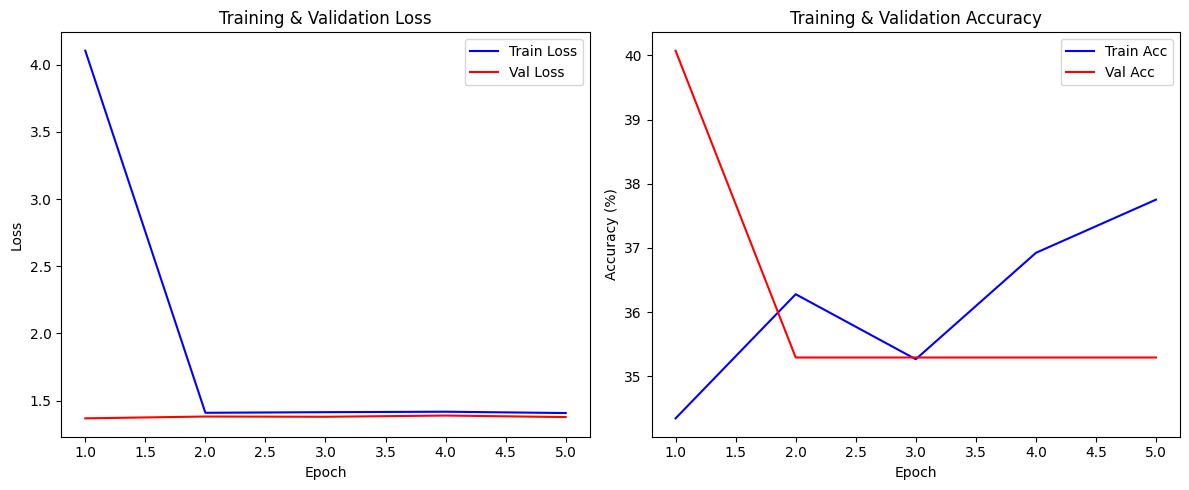


Test Accuracy: 36.82%


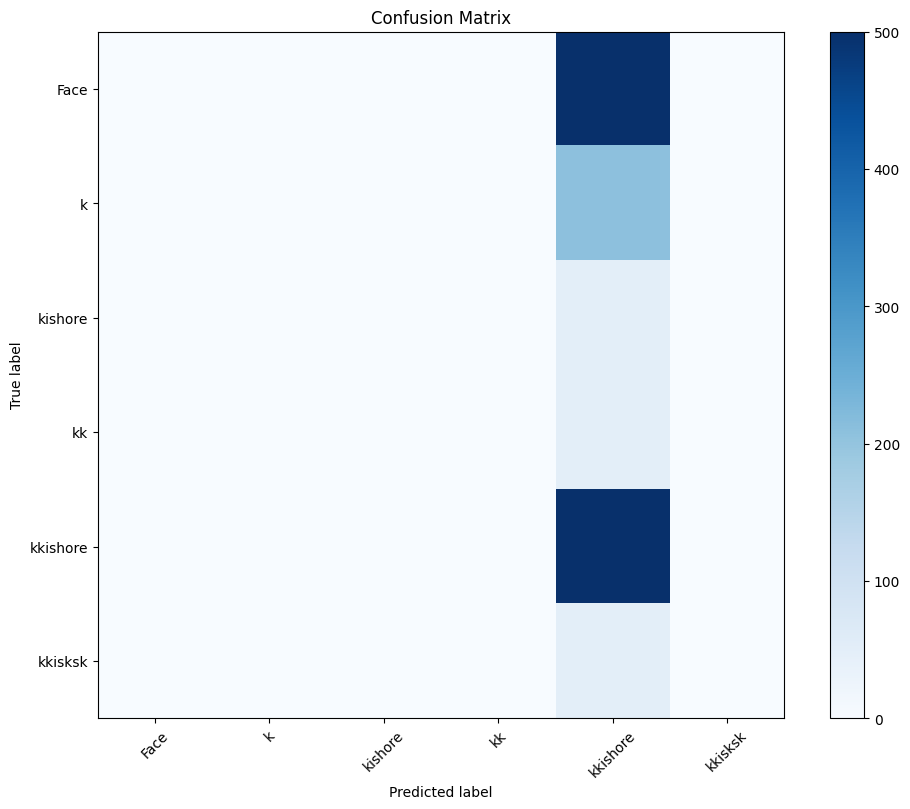

In [6]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
import numpy as np

# Configuration
class Config:
    data_dir = 'face_dataset'  # Path to your face dataset
    batch_size = 16
    learning_rate = 0.001
    num_epochs = 5
    use_cuda = torch.cuda.is_available()
    save_path = 'vgg16_face_model.pth'

# Data Preprocessing and Augmentation
def get_data_transforms():
    train_transforms = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                              std=[0.229, 0.224, 0.225])
    ])
    
    test_transforms = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                              std=[0.229, 0.224, 0.225])
    ])
    
    return train_transforms, test_transforms

# Load Dataset
def load_dataset(data_dir, train_transforms, test_transforms):
    # Load dataset from subfolders
    full_dataset = datasets.ImageFolder(
        root=data_dir, 
        transform=train_transforms
    )
    
    # Split into train and validation
    train_size = int(0.8 * len(full_dataset))
    val_size = len(full_dataset) - train_size
    train_dataset, val_dataset = torch.utils.data.random_split(
        full_dataset, [train_size, val_size]
    )
    
    # Create test dataset
    test_dataset = datasets.ImageFolder(
        root=data_dir, 
        transform=test_transforms
    )
    
    # Create data loaders
    train_loader = DataLoader(
        train_dataset, 
        batch_size=Config.batch_size, 
        shuffle=True
    )
    val_loader = DataLoader(
        val_dataset, 
        batch_size=Config.batch_size, 
        shuffle=False
    )
    test_loader = DataLoader(
        test_dataset, 
        batch_size=Config.batch_size, 
        shuffle=False
    )
    
    return train_loader, val_loader, test_loader, full_dataset.classes

# Custom VGG16 Model
def create_vgg16_model(num_classes):
    model = models.vgg16(weights=None)
    
    # Modify the final fully connected layer
    model.classifier[6] = nn.Linear(
        model.classifier[6].in_features, 
        num_classes
    )
    
    return model

# Training Function
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs, classes):
    device = torch.device('cuda' if Config.use_cuda else 'cpu')
    model.to(device)
    
    # Tracking metrics
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []
    
    for epoch in range(num_epochs):
        # Training Phase
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0
        
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()
        
        # Validation Phase
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()
        
        # Calculate metrics
        train_epoch_loss = train_loss / len(train_loader)
        val_epoch_loss = val_loss / len(val_loader)
        train_epoch_acc = 100 * train_correct / train_total
        val_epoch_acc = 100 * val_correct / val_total
        
        train_losses.append(train_epoch_loss)
        val_losses.append(val_epoch_loss)
        train_accuracies.append(train_epoch_acc)
        val_accuracies.append(val_epoch_acc)
        
        print(f'Epoch {epoch+1}/{num_epochs}:')
        print(f'Train Loss: {train_epoch_loss:.4f}, Train Acc: {train_epoch_acc:.2f}%')
        print(f'Val Loss: {val_epoch_loss:.4f}, Val Acc: {val_epoch_acc:.2f}%')
    
        # Save the model
    torch.save({
        'model_state_dict': model.state_dict(),
        'classes': classes   # pass classes into train_model() or store globally
    }, Config.save_path)
    print(f'Model saved to {Config.save_path}')
    return model, train_losses, val_losses, train_accuracies, val_accuracies

# Main Execution
def main():
    # Set random seed for reproducibility
    torch.manual_seed(42)
    
    # Data Transforms
    train_transforms, test_transforms = get_data_transforms()
    
    # Load Dataset
    train_loader, val_loader, test_loader, classes = load_dataset(
        Config.data_dir, train_transforms, test_transforms
    )
    
    # Create Model
    model = create_vgg16_model(len(classes))
    
    # Loss and Optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=Config.learning_rate)
    
    # Train Model
    trained_model, train_losses, val_losses, train_accuracies, val_accuracies = train_model(
    model, train_loader, val_loader, criterion, optimizer, Config.num_epochs, classes
)
    
    # Plot Performance
    plot_performance(train_losses, val_losses, train_accuracies, val_accuracies)
    
    # Test Model
    confusion_matrix = test_model(trained_model, test_loader, classes)
    
    # Optional: Visualize Confusion Matrix
    plt.figure(figsize=(10, 8))
    plt.imshow(confusion_matrix, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title('Confusion Matrix')
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)
    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()

if __name__ == "__main__":
    main()

In [7]:
import cv2
import torch
import numpy as np
from torchvision import transforms, models
from PIL import Image

# Configuration
class Config:
    model_path = 'vgg16_face_model.pth'
    use_cuda = torch.cuda.is_available()
    face_cascade_path = cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'

# Load Model
def load_model(num_classes, checkpoint):
    model = models.vgg16(weights=None)
    model.classifier[6] = torch.nn.Linear(model.classifier[6].in_features, num_classes)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    return model

# Preprocess Image
def preprocess_face(face):
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    return transform(face).unsqueeze(0)

# Live Face Recognition
def recognize_faces():
    device = torch.device('cuda' if Config.use_cuda else 'cpu')
    checkpoint = torch.load(Config.model_path)
    classes = checkpoint.get('classes',None)
    if classes is None:
        print('error')
        exit()
    model = load_model(len(classes)).to(device)
    
    face_cascade = cv2.CascadeClassifier(Config.face_cascade_path)
    cap = cv2.VideoCapture(0)
    
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))
        
        for (x, y, w, h) in faces:
            face_img = frame[y:y+h, x:x+w]
            face_pil = Image.fromarray(cv2.cvtColor(face_img, cv2.COLOR_BGR2RGB))
            input_tensor = preprocess_face(face_pil).to(device)
            
            with torch.no_grad():
                output = model(input_tensor)
                _, predicted = torch.max(output, 1)
                label = classes[predicted.item()]
            
            # Draw bounding box and label
            cv2.rectangle(frame, (x, y), (x+w, y+h), (0, 255, 0), 2)
            cv2.putText(frame, label, (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)
        
        cv2.imshow('Face Recognition', frame)
        
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break
    
    cap.release()
    cv2.destroyAllWindows()

if __name__ == "__main__":
    recognize_faces()

C:\Users\Dr.PVVK\AppData\Local\Temp\ipykernel_27300\3618136799.py:33: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(Config.model_path)


TypeError: load_model() missing 1 required positional argument: 'checkpoint'